In [4]:
from IPython.display import display, HTML

display(HTML(r"""
<style>
/* JupyterLab 4.x: center the notebook area */
.jp-NotebookPanel-notebook,
.jp-NotebookPanel .jp-Notebook {
  width: 85% !important;
  max-width: 1100px !important;
  margin: 0 auto !important;
}

/* Make wide outputs scroll instead of breaking the layout */
.jp-OutputArea-output {
  overflow-x: auto !important;
}
</style>
"""))

%config InlineBackend.figure_format = "svg"
print("Centered JupyterLab notebook + SVG inline figures.")

Centered JupyterLab notebook + SVG inline figures.


In [5]:
import numpy as np
import matplotlib.pyplot as plt

### 1. Neural Units

#### 1.1 Units

In [6]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

def relu(z):
    return np.maximum(0, z)

def neural_unit(x, w, b):
    z = np.dot(w, x) + b
    y = sigmoid(z)
    return z, y

- **Scalar example**

Scalar example
x = 2.0, w = 0.8, b = -0.5
z = 1.1000, y = 0.7503



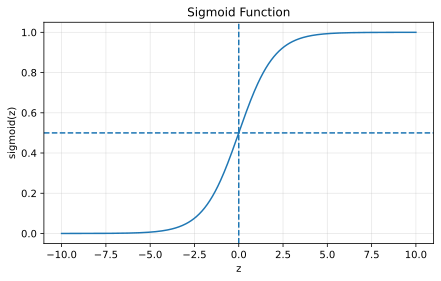

Vector example
x = [ 1.  2. -1.]
w = [ 0.5 -0.3  0.8]
b = 0.1
w·x = -0.9000
z = -0.8000
y = 0.3100



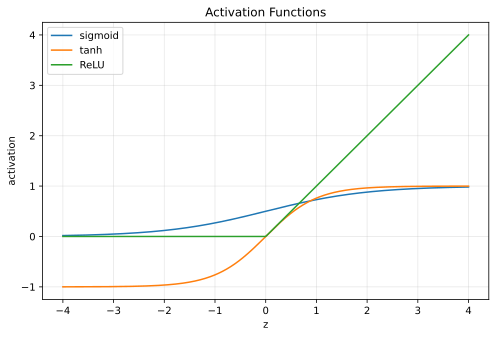

In [7]:
x = 2.0
w = 0.8
b = -0.5
z = w * x + b
y = sigmoid(z)

print("Scalar example")
print(f"x = {x}, w = {w}, b = {b}")
print(f"z = {z:.4f}, y = {y:.4f}")
print()

# 2. Plot sigmoid
z_values = np.linspace(-10, 10, 400)
plt.figure(figsize=(7, 4))
plt.plot(z_values, sigmoid(z_values))
plt.axhline(0.5, linestyle="--")
plt.axvline(0, linestyle="--")
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Sigmoid Function")
plt.grid(True, alpha=0.3)
plt.show()

# 3. Vector example
x = np.array([1.0, 2.0, -1.0])
w = np.array([0.5, -0.3, 0.8])
b = 0.1

z, y = neural_unit(x, w, b)
print("Vector example")
print("x =", x)
print("w =", w)
print("b =", b)
print(f"w·x = {np.dot(w, x):.4f}")
print(f"z = {z:.4f}")
print(f"y = {y:.4f}")
print()

# 4. Compare activations
z_values = np.linspace(-4, 4, 400)
plt.figure(figsize=(8, 5))
plt.plot(z_values, sigmoid(z_values), label="sigmoid")
plt.plot(z_values, tanh(z_values), label="tanh")
plt.plot(z_values, relu(z_values), label="ReLU")
plt.xlabel("z")
plt.ylabel("activation")
plt.title("Activation Functions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 2. NPLM

- NPLM paper: 

In [8]:
import torch
import torch.nn as nn
from dataclasses import dataclass
from typing import Optional, Tuple

from transformers import PretrainedConfig, PreTrainedModel
from transformers.modeling_outputs import CausalLMOutput


class NPLMConfig(PretrainedConfig):
    model_type = "bengio_nplm"

    def __init__(
        self,
        vocab_size: int = 10000,
        context_size: int = 3,      # number of previous words used
        embedding_dim: int = 60,    # m in the paper
        hidden_dim: int = 50,      # h in the paper
        use_direct_connections: bool = True,  # whether to include W x
        pad_token_id: int = 0,
        bos_token_id: int = 1,
        eos_token_id: int = 2,
        **kwargs,
    ):
        super().__init__(
            pad_token_id=pad_token_id,
            bos_token_id=bos_token_id,
            eos_token_id=eos_token_id,
            **kwargs,
        )
        self.vocab_size = vocab_size
        self.context_size = context_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.use_direct_connections = use_direct_connections


class BengioNPLM(PreTrainedModel):
    config_class = NPLMConfig

    def __init__(self, config: NPLMConfig):
        super().__init__(config)
        
        self.emb = nn.Embedding(config.vocab_size, config.embedding_dim) # W
        input_dim = config.context_size * config.embedding_dim
        self.hidden = nn.Linear(input_dim, config.hidden_dim) # Hx + d
        self.hidden_to_vocab = nn.Linear(config.hidden_dim, config.vocab_size, bias=False) # U tanh(...)
        self.output_bias = nn.Parameter(torch.zeros(config.vocab_size)) # b + W x
        self.direct = (nn.Linear(input_dim, config.vocab_size, bias=False)
                       if config.use_direct_connections else None)
        self.post_init()

    def forward(
        self,
        input_ids: torch.LongTensor,   # [batch, context_size]
        labels: Optional[torch.LongTensor] = None,  # [batch]
        **kwargs,
    ) -> CausalLMOutput:
        """
        input_ids: previous context words only, shape [B, context_size]
        labels: next-token target, shape [B]
        """
        if input_ids.dim() != 2:
            raise ValueError(f"input_ids must have shape \
            [batch, context_size], got {input_ids.shape}")

        if input_ids.size(1) != self.config.context_size:
            raise ValueError(
                f"Expected context_size={self.config.context_size}, "
                f"but got input length {input_ids.size(1)}"
            )
        # x = concat(C(w_{t-1}), C(w_{t-2}), ..., C(w_{t-n+1}))
        x = self.emb(input_ids)                      # [B, context_size, emb_dim]
        x = x.reshape(x.size(0), -1)                # [B, context_size * emb_dim]
        h = torch.tanh(self.hidden(x))              # tanh(d + Hx)
        logits = self.hidden_to_vocab(h) + self.output_bias  # U tanh(...) + b
        if self.direct is not None:
            logits = logits + self.direct(x)        # + W x
        loss = None
        if labels is not None:
            loss = nn.functional.cross_entropy(logits, labels)
        return CausalLMOutput(
            loss=loss,
            logits=logits,
        )

    @torch.no_grad()
    def predict_next(
        self, input_ids: torch.LongTensor, top_k: int = 5
    )-> Tuple[torch.Tensor, torch.Tensor]:
        """
        Returns top-k probabilities and token ids.
        input_ids: [B, context_size]
        """
        outputs = self(input_ids=input_ids)
        probs = torch.softmax(outputs.logits, dim=-1)
        top_probs, top_ids = torch.topk(probs, k=top_k, dim=-1)
        return top_probs, top_ids

In [9]:
from torch.utils.data import Dataset


class NPLMTextDataset(Dataset):
    def __init__(self, token_ids, context_size: int):
        """
        token_ids: a flat list of token ids
        Produces pairs:
          input  = token_ids[i : i+context_size]
          target = token_ids[i+context_size]
        """
        self.token_ids = token_ids
        self.context_size = context_size

    def __len__(self):
        return max(0, len(self.token_ids) - self.context_size)

    def __getitem__(self, idx):
        x = self.token_ids[idx : idx + self.context_size]
        y = self.token_ids[idx + self.context_size]
        return {
            "input_ids": torch.tensor(x, dtype=torch.long),
            "labels": torch.tensor(y, dtype=torch.long),
        }

- **Use a tiny dataset to verify the code and model.**

#### 2.1 Test on tiny toy dataset

epoch=00 loss=10.8225
epoch=01 loss=10.8034
epoch=02 loss=10.7840
epoch=03 loss=10.7620
epoch=04 loss=10.7360
epoch=05 loss=10.7050
epoch=06 loss=10.6686
epoch=07 loss=10.6234
epoch=08 loss=10.5681
epoch=09 loss=10.5002
epoch=10 loss=10.4170
epoch=11 loss=10.3166
epoch=12 loss=10.1947
epoch=13 loss=10.0465
epoch=14 loss=9.8636
epoch=15 loss=9.6448
epoch=16 loss=9.3867
epoch=17 loss=9.0775
epoch=18 loss=8.7091
epoch=19 loss=8.2773
epoch=20 loss=7.7749
epoch=21 loss=7.1993
epoch=22 loss=6.5442
epoch=23 loss=5.8073
epoch=24 loss=4.9940
epoch=25 loss=4.1419
epoch=26 loss=3.3325
epoch=27 loss=2.6814
epoch=28 loss=2.2859
epoch=29 loss=2.1113
epoch=30 loss=2.0390
epoch=31 loss=1.9980
epoch=32 loss=1.9723
epoch=33 loss=1.9523
epoch=34 loss=1.9346
epoch=35 loss=1.9206
epoch=36 loss=1.8978
epoch=37 loss=1.8765
epoch=38 loss=1.8571
epoch=39 loss=1.8379
epoch=40 loss=1.8151
epoch=41 loss=1.7967
epoch=42 loss=1.7686
epoch=43 loss=1.7463
epoch=44 loss=1.7161
epoch=45 loss=1.6909
epoch=46 loss=1.6641

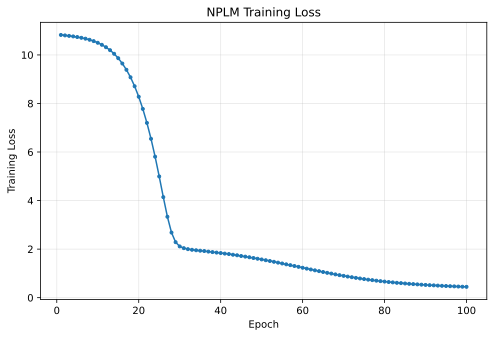

In [10]:
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

# Example tokenizer; for teaching/demo this is convenient.
# Any tokenizer is fine as long as it returns integer ids.
tokenizer = AutoTokenizer.from_pretrained("gpt2")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

text = """
the cat sat on the mat .
the dog sat on the rug .
the cat chased the dog .
the dog chased the cat .
"""

enc = tokenizer(text, add_special_tokens=False)
token_ids = enc["input_ids"]

context_size = 3
dataset = NPLMTextDataset(token_ids, context_size=context_size)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

config = NPLMConfig(
    vocab_size=tokenizer.vocab_size,
    context_size=context_size,
    embedding_dim=64,
    hidden_dim=128,
    use_direct_connections=True,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = BengioNPLM(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

num_epochs = 100
epoch_losses = []

model.train()
for epoch in tqdm(range(num_epochs)):
    total_loss = 0.0
    total_items = 0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        bs = input_ids.size(0)
        total_loss += loss.item() * bs
        total_items += bs

    avg_loss = total_loss / max(total_items, 1)
    epoch_losses.append(avg_loss)
    print(f"epoch={epoch:02d} loss={avg_loss:.4f}")

# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), epoch_losses, marker='o', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("NPLM Training Loss")
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
model.eval()

prompt = "the cat sat"
prompt_ids = tokenizer(
    prompt, add_special_tokens=False)["input_ids"]

# keep only last `context_size` tokens
context = prompt_ids[-context_size:]
if len(context) < context_size:
    context = [tokenizer.pad_token_id] * (context_size - len(context)) + context

print(context_size, context)
x = torch.tensor([context], dtype=torch.long).to(device)
top_probs, top_ids = model.predict_next(x, top_k=5)

for p, idx in zip(top_probs[0].tolist(), top_ids[0].tolist()):
    print(f"{tokenizer.decode([idx]).strip()!r}: {p:.4f}")

3 [1169, 3797, 3332]
'on': 0.5458
'the': 0.2058
'': 0.0792
'the': 0.0447
'dog': 0.0236


#### 2.2 Test on wikitext dataset

In [24]:
from datasets import load_dataset
ds = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")
print(ds["train"])

Dataset({
    features: ['text'],
    num_rows: 36718
})


In [25]:
print(ds)

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})


In [ ]:
import math
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from transformers import AutoTokenizer, PretrainedConfig, PreTrainedModel
from transformers.modeling_outputs import CausalLMOutput
from typing import Optional


class NPLMTextDataset(Dataset):
    def __init__(self, token_ids, context_size: int):
        self.token_ids = token_ids
        self.context_size = context_size

    def __len__(self):
        return max(0, len(self.token_ids) - self.context_size)

    def __getitem__(self, idx):
        x = self.token_ids[idx : idx + self.context_size]
        y = self.token_ids[idx + self.context_size]
        return {
            "input_ids": torch.tensor(x, dtype=torch.long),
            "labels": torch.tensor(y, dtype=torch.long),
        }


def tokenize_split(text_list, tokenizer):
    text_list = [x for x in text_list if x is not None and len(x.strip()) > 0]
    full_text = "\n".join(text_list)
    enc = tokenizer(full_text, add_special_tokens=False)
    return enc["input_ids"]


class NPLMConfig(PretrainedConfig):
    model_type = "bengio_nplm"

    def __init__(
        self,
        vocab_size=10000,
        context_size=5,
        embedding_dim=128,
        hidden_dim=256,
        use_direct_connections=True,
        pad_token_id=0,
        bos_token_id=1,
        eos_token_id=2,
        **kwargs,
    ):
        super().__init__(
            pad_token_id=pad_token_id,
            bos_token_id=bos_token_id,
            eos_token_id=eos_token_id,
            **kwargs,
        )
        self.vocab_size = vocab_size
        self.context_size = context_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.use_direct_connections = use_direct_connections


class BengioNPLM(PreTrainedModel):
    config_class = NPLMConfig

    def __init__(self, config):
        super().__init__(config)

        self.emb = nn.Embedding(config.vocab_size, config.embedding_dim)
        input_dim = config.context_size * config.embedding_dim

        self.hidden = nn.Linear(input_dim, config.hidden_dim)
        self.hidden_to_vocab = nn.Linear(config.hidden_dim, config.vocab_size, bias=False)
        self.output_bias = nn.Parameter(torch.zeros(config.vocab_size))

        self.direct = (
            nn.Linear(input_dim, config.vocab_size, bias=False)
            if config.use_direct_connections else None
        )

        self.post_init()

    def forward(self, input_ids, labels: Optional[torch.LongTensor] = None, **kwargs):
        x = self.emb(input_ids)          # [B, context, emb]
        x = x.reshape(x.size(0), -1)     # [B, context*emb]

        h = torch.tanh(self.hidden(x))
        logits = self.hidden_to_vocab(h) + self.output_bias

        if self.direct is not None:
            logits = logits + self.direct(x)

        loss = None
        if labels is not None:
            loss = nn.functional.cross_entropy(logits, labels)

        return CausalLMOutput(loss=loss, logits=logits)

    @torch.no_grad()
    def predict_next(self, input_ids, top_k=5):
        outputs = self(input_ids=input_ids)
        probs = torch.softmax(outputs.logits, dim=-1)
        return torch.topk(probs, k=top_k, dim=-1)


def train_one_epoch(model, data_loader, optimizer, device):
    model.train()
    total_loss = 0.0
    total_items = 0

    for batch in data_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        bs = input_ids.size(0)
        total_loss += loss.item() * bs
        total_items += bs

    avg_loss = total_loss / max(total_items, 1)
    return avg_loss, math.exp(avg_loss)


@torch.no_grad()
def evaluate(model, data_loader, device):
    model.eval()
    total_loss = 0.0
    total_items = 0

    for batch in data_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, labels=labels)
        loss = outputs.loss

        bs = input_ids.size(0)
        total_loss += loss.item() * bs
        total_items += bs

    avg_loss = total_loss / max(total_items, 1)
    return avg_loss, math.exp(avg_loss)


# ---------------------------
# Load dataset
# ---------------------------
ds = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")

tokenizer = AutoTokenizer.from_pretrained("gpt2")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

context_size = 5
batch_size = 128
num_epochs = 10
device = "cuda" if torch.cuda.is_available() else "cpu"

train_ids = tokenize_split(ds["train"]["text"], tokenizer)
valid_ids = tokenize_split(ds["validation"]["text"], tokenizer)
test_ids  = tokenize_split(ds["test"]["text"], tokenizer)

train_dataset = NPLMTextDataset(train_ids, context_size)
valid_dataset = NPLMTextDataset(valid_ids, context_size)
test_dataset  = NPLMTextDataset(test_ids, context_size)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

config = NPLMConfig(
    vocab_size=tokenizer.vocab_size,
    context_size=context_size,
    embedding_dim=128,
    hidden_dim=256,
    use_direct_connections=True,
    pad_token_id=tokenizer.pad_token_id,
    eos_token_id=tokenizer.eos_token_id,
)

model = BengioNPLM(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)

best_valid_loss = float("inf")
best_state_dict = None

for epoch in range(1, num_epochs + 1):
    train_loss, train_ppl = train_one_epoch(model, train_loader, optimizer, device)
    valid_loss, valid_ppl = evaluate(model, valid_loader, device)

    print(
        f"Epoch {epoch:02d} | "
        f"train loss={train_loss:.4f} ppl={train_ppl:.2f} | "
        f"valid loss={valid_loss:.4f} ppl={valid_ppl:.2f}"
    )

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

test_loss, test_ppl = evaluate(model, test_loader, device)
print(f"\nBest validation loss: {best_valid_loss:.4f}")
print(f"Test loss: {test_loss:.4f}")
print(f"Test perplexity: {test_ppl:.2f}")

Token indices sequence length is longer than the specified maximum sequence length for this model (2391884 > 1024). Running this sequence through the model will result in indexing errors
